<a href="https://colab.research.google.com/github/nimasha20020207/DL_Assignment_Y4S1/blob/main/IT23322912.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weerathunga V.K - IT23322912


# **Wide & Deep Network for Breast Cancer Classification**

### **Model:**   Wide & Deep Network (W&D)
### **Task:**    Binary Classification

## 1. Setup and Imports

In [27]:
!pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate
)
from keras.models import Model
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
# Suppress FutureWarnings for cleaner output
warnings.filterwarnings("ignore")

Reproducibility

In [29]:
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully.")
print("Random seed: 42")

Libraries loaded successfully.
Random seed: 42


## 2. Data Loading and Initial Inspection

In [30]:
df = pd.read_csv("/content/Cancer_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [32]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [33]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


## 3. Data Cleaning

In [34]:
# Remove unnecessary columns
df = df.drop(columns=['Unnamed: 32', 'id'])

# Check cleaned dataset
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Dataset shape: (569, 31)
Missing values: 0
Duplicate rows: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Target Preparation

In [35]:
# Convert diagnosis labels into numeric values
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Check the encoded target values
print(df['diagnosis'].value_counts())
# in here 0 = Benign, 1 = Malignant.

diagnosis
0    357
1    212
Name: count, dtype: int64


## 5. Feature and Target Separation

In [36]:
# Separate input features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


## 6. Train, Validation and Test Split

In [37]:
# Split data into training and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temporary set equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (398, 30) (398,)
Validation set: (85, 30) (85,)
Test set: (86, 30) (86,)


## 7. Exploratory Data Analysis

### Class Distribution

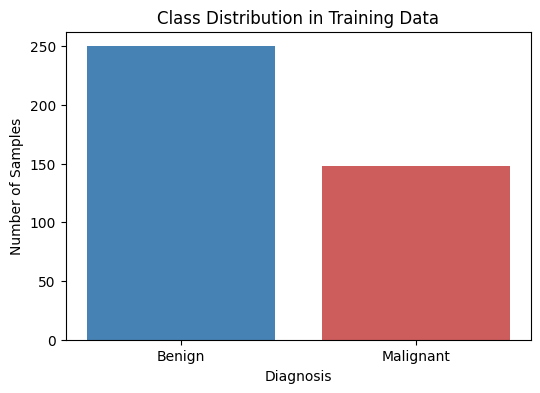

diagnosis
0    250
1    148
Name: count, dtype: int64


In [38]:
# Class distribution in the training set
class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ['Benign', 'Malignant'],
    class_counts.values,
    color=['steelblue', 'indianred']
)

plt.title('Class Distribution in Training Data')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Samples')

plt.show()

print(class_counts)

### Correlation Heatmap

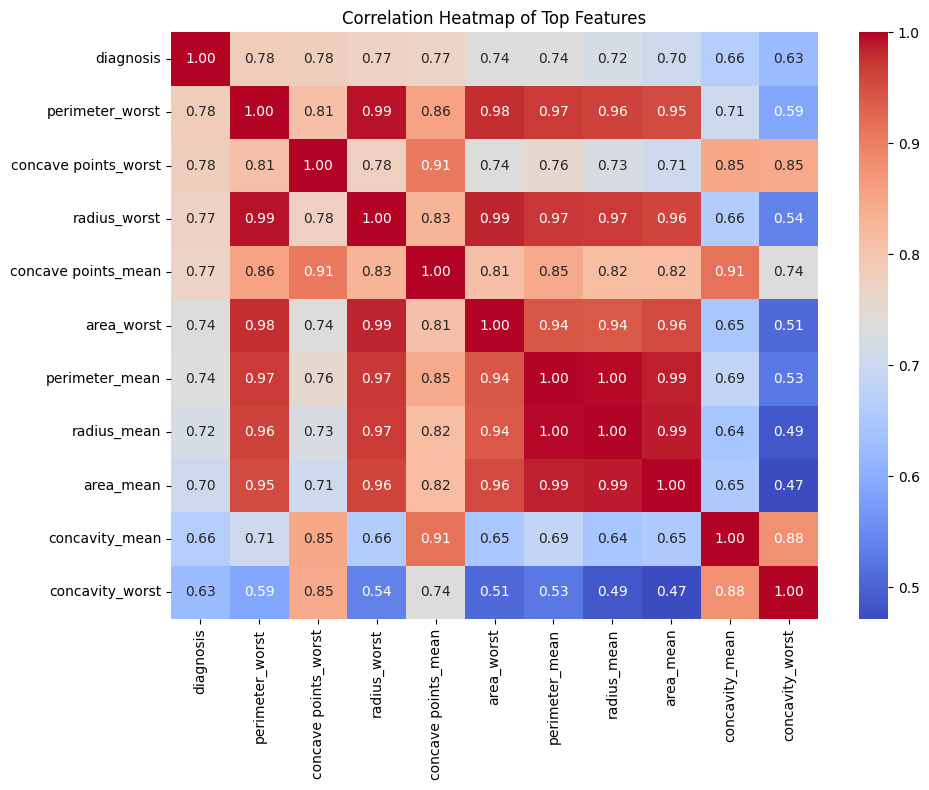

In [39]:
# Create a training dataframe for correlation analysis
train_data = X_train.copy()
train_data['diagnosis'] = y_train

# Find features with the highest correlation with diagnosis
correlation = train_data.corr()['diagnosis'].abs().sort_values(ascending=False)

top_features = correlation.head(11).index

# Plot correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    train_data[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()

### Feature Correlation with Diagnosis

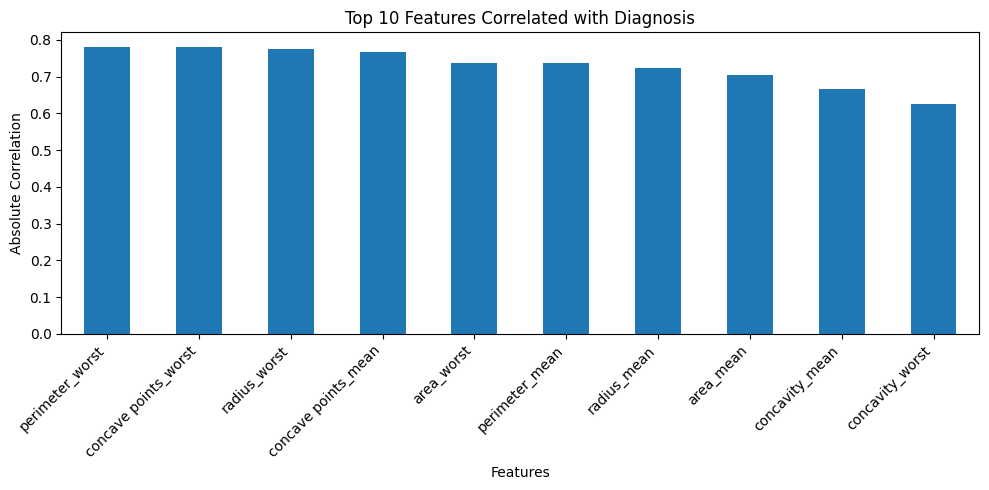

In [40]:
# Calculate correlation of training features with diagnosis
train_corr_data = X_train.copy()
train_corr_data['diagnosis'] = y_train

feature_correlations = (
    train_corr_data.corr()['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
)

# Plot the 10 most correlated features
top_10_correlations = feature_correlations.head(10)

plt.figure(figsize=(10, 5))
top_10_correlations.plot(kind='bar')

plt.title('Top 10 Features Correlated with Diagnosis')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Distribution by Diagnosis

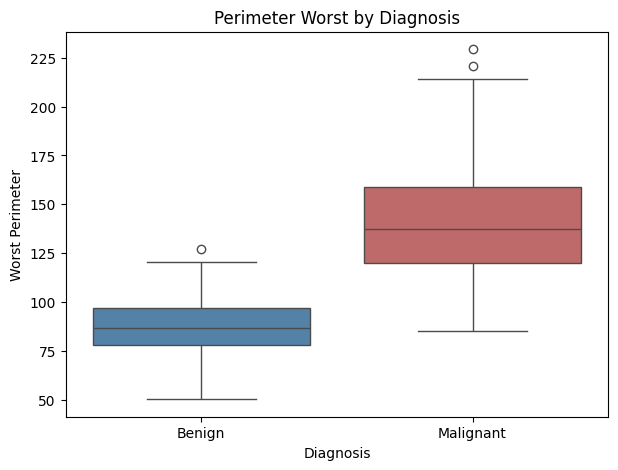

In [41]:
# Compare perimeter_worst between benign and malignant cases
plot_data = X_train.copy()
plot_data['diagnosis'] = y_train

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_data,
    x='diagnosis',
    y='perimeter_worst',
    hue='diagnosis',
    palette={0: 'steelblue', 1: 'indianred'},
    legend=False
)

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.title('Perimeter Worst by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Worst Perimeter')

plt.show()

## 8. Feature Selection Decision

All 30 input features were retained for model training. Features were not removed based only on correlation values.

## 9. Feature Scaling

In [42]:
# Standardize the input features
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Training: (398, 30)
Validation: (85, 30)
Test: (86, 30)


## 10. Wide and Deep Model Architecture

The Wide and Deep model combines linear and non-linear feature learning for breast cancer classification.

In [43]:
# Number of input features
input_dim = X_train_scaled.shape[1]

# Input layer
inputs = Input(shape=(input_dim,), name='Input_Features')

# Wide component
wide_output = Dense(
    1,
    activation=None,
    name='Wide_Output'
)(inputs)

# Deep component - Layer 1
deep = Dense(
    128,
    activation='relu',
    name='Deep_Dense_1'
)(inputs)

deep = BatchNormalization(name='Deep_BN_1')(deep)
deep = Dropout(0.30, name='Deep_Dropout_1')(deep)

# Deep component - Layer 2
deep = Dense(
    64,
    activation='relu',
    name='Deep_Dense_2'
)(deep)

deep = BatchNormalization(name='Deep_BN_2')(deep)
deep = Dropout(0.30, name='Deep_Dropout_2')(deep)

# Deep component - Layer 3
deep = Dense(
    32,
    activation='relu',
    name='Deep_Dense_3'
)(deep)

# Deep output
deep_output = Dense(
    1,
    activation=None,
    name='Deep_Output'
)(deep)

# Combine Wide and Deep outputs
combined = keras.layers.Add(
    name='Wide_Deep_Add'
)([wide_output, deep_output])

# Final binary classification
output = keras.layers.Activation(
    'sigmoid',
    name='Prediction'
)(combined)

# Create model
wide_deep_model = Model(
    inputs=inputs,
    outputs=output,
    name='Wide_Deep_Model'
)

wide_deep_model.summary()

Model: "Wide_Deep_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Features      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dense_1        │ (None, 128)       │      3,968 │ Input_Features[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_BN_1           │ (None, 128)       │        512 │ Deep_Dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dropout_1      │ (None, 128)       │          0 │ Deep_BN_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dense_2        │ (None, 64)        │      8,256 │ Deep_Dropout_1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_BN_2           │ (None, 64)        │        256 │ Deep_Dense_2[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dropout_2      │ (None, 64)        │          0 │ Deep_BN_2[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Dense_3        │ (None, 32)        │      2,080 │ Deep_Dropout_2[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Output (Dense) │ (None, 1)         │         31 │ Input_Features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_Output (Dense) │ (None, 1)         │         33 │ Deep_Dense_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Deep_Add (Add) │ (None, 1)         │          0 │ Wide_Output[0][0… │
│                     │                   │            │ Deep_Output[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Prediction          │ (None, 1)         │          0 │ Wide_Deep_Add[0]… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,136 (59.12 KB)

 Trainable params: 14,752 (57.62 KB)

 Non-trainable params: 384 (1.50 KB)

 ## 11. Model Compilation and Training

In [44]:
# Compile the model
wide_deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc')
    ]
)

# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

# Train the model
history = wide_deep_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("Model training completed.")
print("Epochs completed:", len(history.history['loss']))

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6910 - auc: 0.8286 - loss: 0.6704 - val_accuracy: 0.8235 - val_auc: 0.9475 - val_loss: 0.4361
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8869 - auc: 0.9593 - loss: 0.2908 - val_accuracy: 0.8706 - val_auc: 0.9688 - val_loss: 0.3267
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9271 - auc: 0.9791 - loss: 0.1941 - val_accuracy: 0.9059 - val_auc: 0.9776 - val_loss: 0.2672
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9472 - auc: 0.9840 - loss: 0.1609 - val_accuracy: 0.9294 - val_auc: 0.9885 - val_loss: 0.2196
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9548 - auc: 0.9907 - loss: 0.1220 - val_accuracy: 0.9412 - val_auc: 0.9938 - val_loss: 0.1862
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9497 - auc: 0.9913 - loss: 0.1241 - val_accuracy: 0.9647 - val_auc: 0.9947 - val_loss: 0.1628
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9

## 12. Training History Analysis

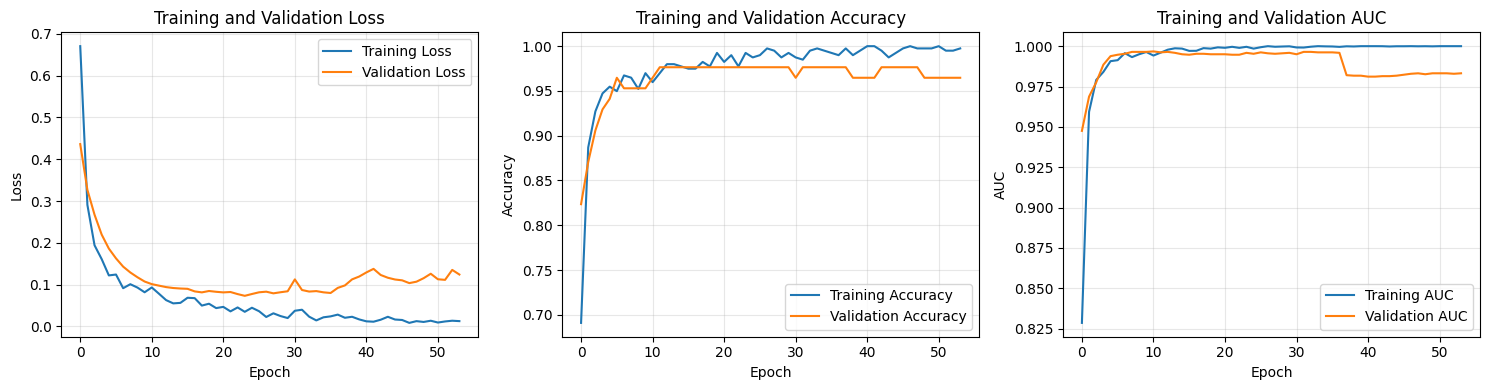

Training completed after 54 epochs


In [45]:
plt.figure(figsize=(15, 4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# AUC
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Training completed after", len(history.history['loss']), "epochs")

## 13. Final Model Evaluation

In [46]:
# Evaluate the model on the unseen test set
test_loss, test_accuracy, test_auc = wide_deep_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

# Generate predictions
y_pred_prob = wide_deep_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Calculate additional metrics
test_precision = precision_score(y_test, y_pred_class)
test_recall = recall_score(y_test, y_pred_class)
test_f1 = f1_score(y_test, y_pred_class)
test_roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Final Test Results")
print("------------------")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")
print(f"Test ROC-AUC   : {test_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_class,
        target_names=['Benign', 'Malignant']
    )
)

Final Test Results
------------------
Test Loss      : 0.0494
Test Accuracy  : 0.9767
Test Precision : 1.0000
Test Recall    : 0.9375
Test F1-Score  : 0.9677
Test ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        54
   Malignant       1.00      0.94      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86



### Confusion Matrix

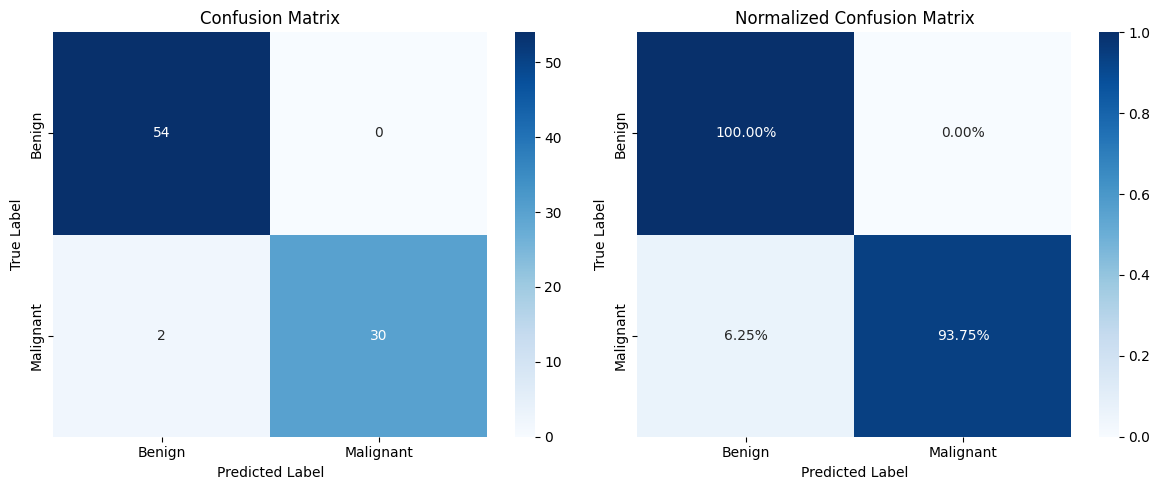

Confusion Matrix Analysis
-------------------------
True Negatives : 54
False Positives: 0
False Negatives: 2
True Positives : 30
Total Samples  : 86


In [47]:
cm = confusion_matrix(y_test, y_pred_class)

cm_normalized = confusion_matrix(
    y_test,
    y_pred_class,
    normalize='true'
)

plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Normalized Confusion Matrix
plt.subplot(1, 2, 2)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis")
print("-------------------------")
print("True Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives :", cm[1, 1])
print("Total Samples  :", cm.sum())

## 14. ROC and Precision-Recall Analysis

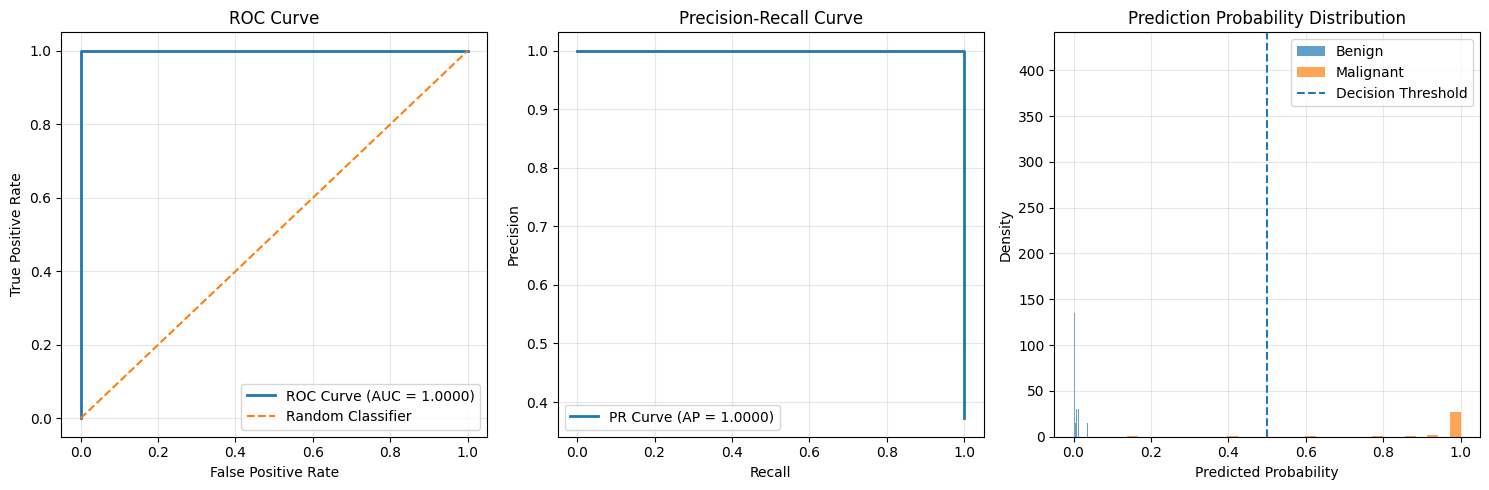

In [48]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(15, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 3, 1)
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)


# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_prob
)

avg_precision = average_precision_score(
    y_test,
    y_pred_prob
)

plt.subplot(1, 3, 2)
plt.plot(
    recall_curve,
    precision_curve,
    lw=2,
    label=f'PR Curve (AP = {avg_precision:.4f})'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)


# Prediction Probability Distribution
plt.subplot(1, 3, 3)

y_test_array = np.asarray(y_test)

plt.hist(
    y_pred_prob[y_test_array == 0],
    bins=30,
    alpha=0.7,
    label='Benign',
    density=True
)

plt.hist(
    y_pred_prob[y_test_array == 1],
    bins=30,
    alpha=0.7,
    label='Malignant',
    density=True
)

plt.axvline(
    x=0.5,
    linestyle='--',
    label='Decision Threshold'
)

plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Prediction Probability Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Comprehensive Model Performance Analysis

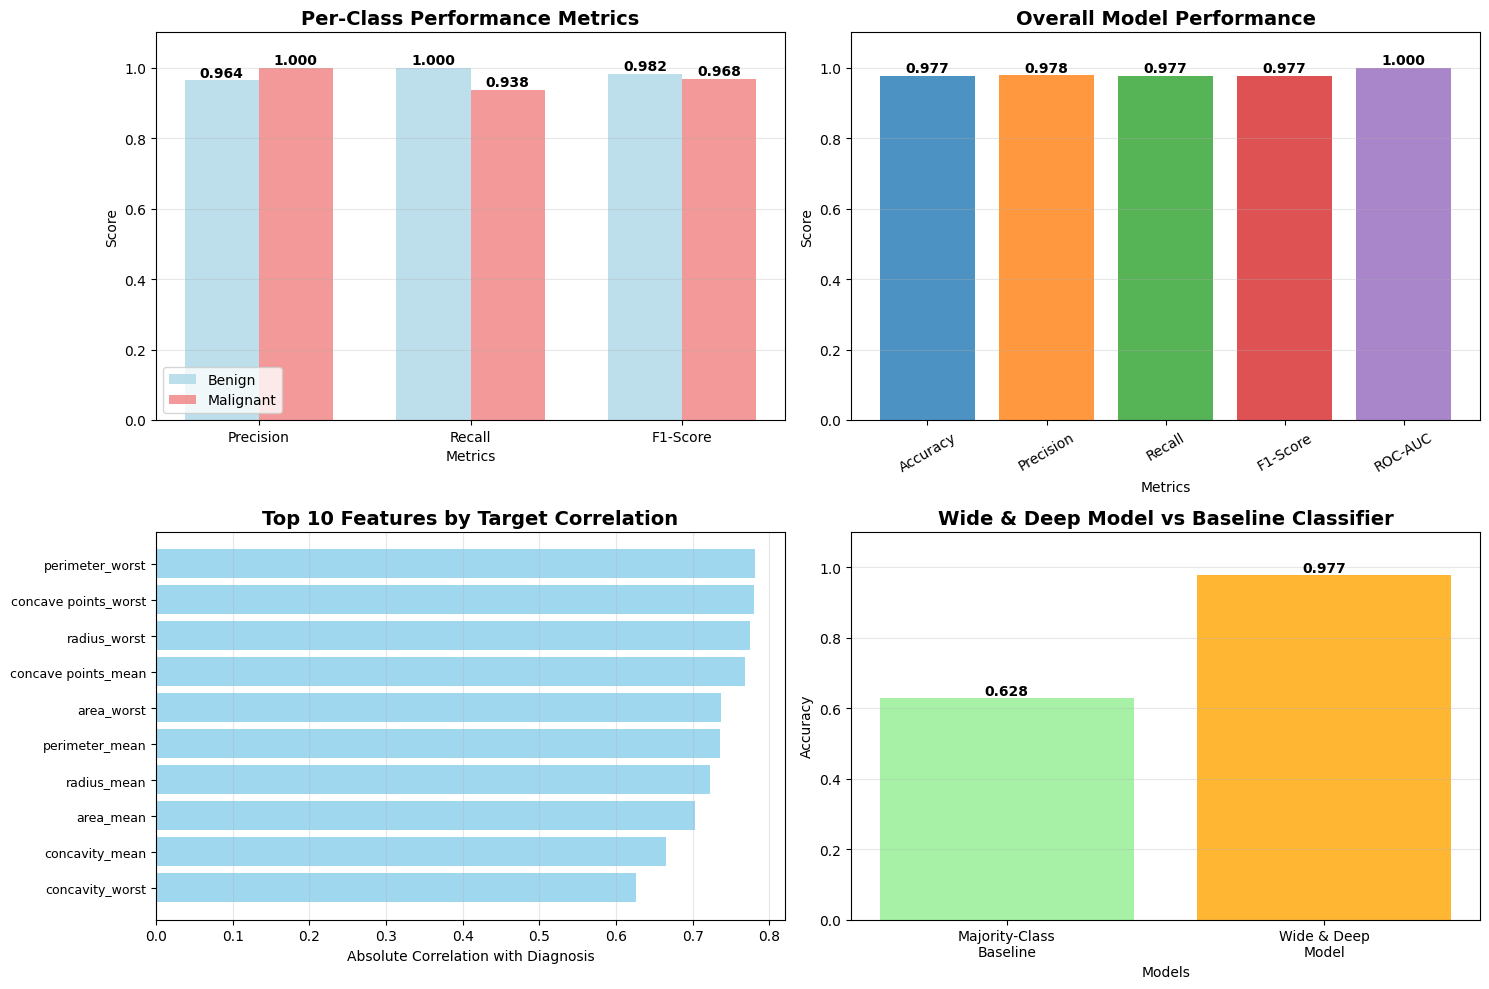

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier

# Calculate per-class metrics
precision_benign = precision_score(
    y_test, y_pred_class, pos_label=0
)
recall_benign = recall_score(
    y_test, y_pred_class, pos_label=0
)
f1_benign = f1_score(
    y_test, y_pred_class, pos_label=0
)

precision_malignant = precision_score(
    y_test, y_pred_class, pos_label=1
)
recall_malignant = recall_score(
    y_test, y_pred_class, pos_label=1
)
f1_malignant = f1_score(
    y_test, y_pred_class, pos_label=1
)

# Calculate overall weighted metrics
overall_precision = precision_score(
    y_test, y_pred_class, average='weighted'
)
overall_recall = recall_score(
    y_test, y_pred_class, average='weighted'
)
overall_f1 = f1_score(
    y_test, y_pred_class, average='weighted'
)


# Create a simple majority-class baseline
baseline_model = DummyClassifier(
    strategy='most_frequent'
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

baseline_accuracy = baseline_model.score(
    X_test_scaled,
    y_test
)


# Create figure
plt.figure(figsize=(15, 10))


# ============================================================
# 1. Per-Class Performance Metrics
# ============================================================

plt.subplot(2, 2, 1)

metrics = [
    'Precision',
    'Recall',
    'F1-Score'
]

benign_scores = [
    precision_benign,
    recall_benign,
    f1_benign
]

malignant_scores = [
    precision_malignant,
    recall_malignant,
    f1_malignant
]

x = np.arange(len(metrics))
width = 0.35

plt.bar(
    x - width/2,
    benign_scores,
    width,
    label='Benign',
    color='lightblue',
    alpha=0.8
)

plt.bar(
    x + width/2,
    malignant_scores,
    width,
    label='Malignant',
    color='lightcoral',
    alpha=0.8
)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title(
    'Per-Class Performance Metrics',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (b, m) in enumerate(
    zip(benign_scores, malignant_scores)
):
    plt.text(
        i - width/2,
        b + 0.01,
        f'{b:.3f}',
        ha='center',
        fontweight='bold'
    )

    plt.text(
        i + width/2,
        m + 0.01,
        f'{m:.3f}',
        ha='center',
        fontweight='bold'
    )


# ============================================================
# 2. Overall Model Performance
# ============================================================

plt.subplot(2, 2, 2)

overall_metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

overall_scores = [
    test_accuracy,
    overall_precision,
    overall_recall,
    overall_f1,
    test_roc_auc
]

bars = plt.bar(
    overall_metrics,
    overall_scores,
    color=[
        '#1f77b4',
        '#ff7f0e',
        '#2ca02c',
        '#d62728',
        '#9467bd'
    ],
    alpha=0.8
)

plt.xlabel('Metrics')
plt.ylabel('Score')

plt.title(
    'Overall Model Performance',
    fontsize=14,
    fontweight='bold'
)

plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, score in zip(
    bars,
    overall_scores
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.01,
        f'{score:.3f}',
        ha='center',
        fontweight='bold'
    )


# ============================================================
# 3. Top 10 Features by Target Correlation
# ============================================================

plt.subplot(2, 2, 3)

top_features = feature_correlations.head(10)

plt.barh(
    range(len(top_features)),
    top_features.values,
    color='skyblue',
    alpha=0.8
)

plt.yticks(
    range(len(top_features)),
    top_features.index,
    fontsize=9
)

plt.xlabel(
    'Absolute Correlation with Diagnosis'
)

plt.title(
    'Top 10 Features by Target Correlation',
    fontsize=14,
    fontweight='bold'
)

# Show strongest correlation at the top
plt.gca().invert_yaxis()

plt.grid(
    True,
    alpha=0.3,
    axis='x'
)


# ============================================================
# 4. Wide & Deep Model vs Baseline Classifier
# ============================================================

plt.subplot(2, 2, 4)

models = [
    'Majority-Class\nBaseline',
    'Wide & Deep\nModel'
]

accuracy_scores = [
    baseline_accuracy,
    test_accuracy
]

bars = plt.bar(
    models,
    accuracy_scores,
    color=[
        'lightgreen',
        'orange'
    ],
    alpha=0.8
)

plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.title(
    'Wide & Deep Model vs Baseline Classifier',
    fontsize=14,
    fontweight='bold'
)

plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, score in zip(
    bars,
    accuracy_scores
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.01,
        f'{score:.3f}',
        ha='center',
        fontweight='bold'
    )


plt.tight_layout()
plt.show()